# **Assignment 1: K-Means on Real-World Data**
• Objective: Apply K-Means to a real-world dataset.

• Task:

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **upload the data**

In [ ]:
df = pd.read_csv('/content/iris_dataset_Full (1).csv')

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df=df.drop('target', axis=1)

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# **Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# **Apply K-Means clustering and determine the optimal number**of clusters using the
Elbow method.

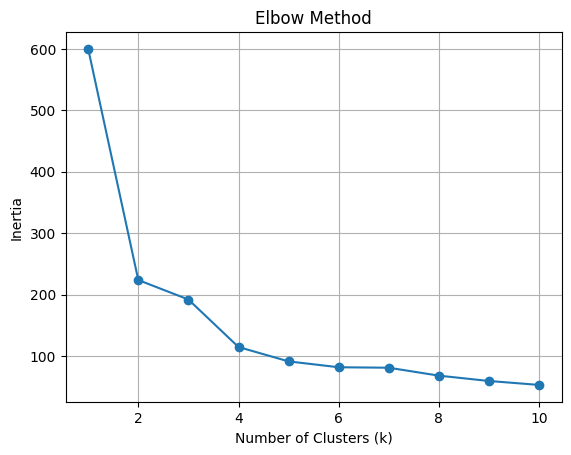

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plotting the elbow
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


# **Visualize the clusters and centroids.**

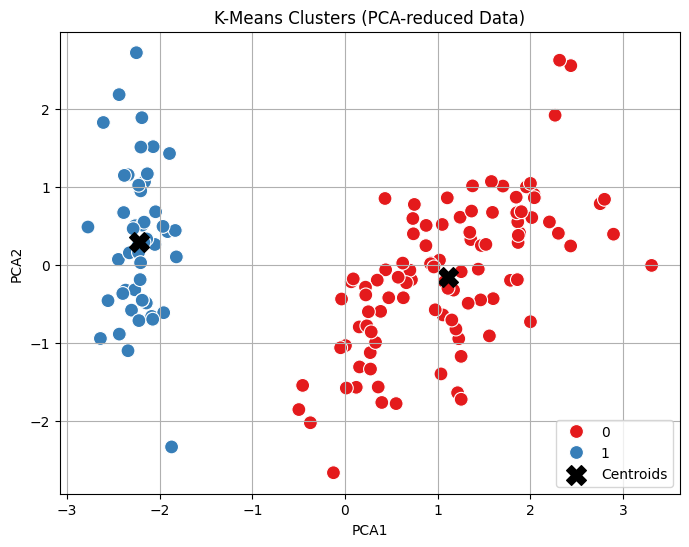

In [ ]:
# Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

# Add cluster labels to DataFrame
df['Cluster'] = clusters

# Visualizing the clusters using PCA
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

# Plotting clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', s=100)
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clusters (PCA-reduced Data)')
plt.legend()
plt.grid(True)
plt.show()


# **Assignment 2: K-Means for Image Compression**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from PIL import Image


In [ ]:
image = Image.open('/content/cat.webp')  # Replace with your image path
image = image.resize((200, 200))  # Resize for faster processing
image_np = np.array(image)


In [ ]:
# Original shape store karo
original_shape = image_np.shape

In [ ]:
original_shape

(200, 200, 3)

In [ ]:
# Image ko 2D array me convert karo — (width * height, 3)
pixels = image_np.reshape(-1, 3)

In [ ]:
pixels

array([[242, 197, 139],
       [241, 196, 135],
       [241, 196, 135],
       ...,
       [166, 169, 172],
       [162, 163, 171],
       [158, 165, 172]], dtype=uint8)

# **Apply K-Means clustering**

In [ ]:
n_colors = 16  # Kitne colors rakhne hain (16 = moderate compression)

# KMeans clustering apply karo
kmeans = KMeans(n_clusters=n_colors, random_state=42)
kmeans.fit(pixels)

# Har pixel ko uske cluster center se replace karo
new_colors = kmeans.cluster_centers_[kmeans.predict(pixels)]


# **Reconstruct the Compressed Image**

In [ ]:
# Reconstructed image banayein original shape me
compressed_image = new_colors.reshape(original_shape).astype(np.uint8)


# **Show Original and Compressed Images**

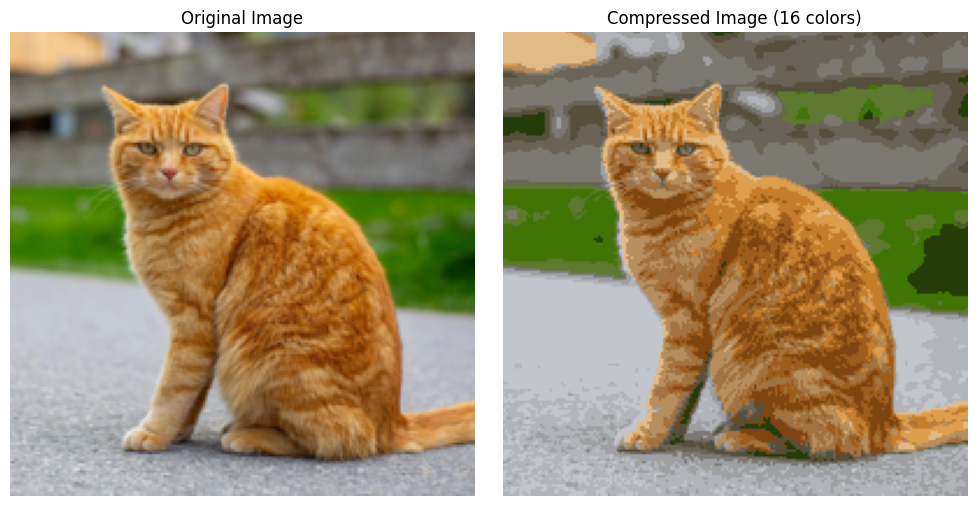

In [ ]:
plt.figure(figsize=(10, 5))

# Original
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_np)
plt.axis('off')

# Compressed
plt.subplot(1, 2, 2)
plt.title(f"Compressed Image ({n_colors} colors)")
plt.imshow(compressed_image)
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Compressed image ko PIL Image me convert karo
compressed_pil = Image.fromarray(compressed_image)

In [ ]:
# Save karo as separate file (e.g., JPEG or PNG)
compressed_pil.save("compressed_output.png")  # or use .jpg

In [ ]:
import os

In [ ]:
# Save both images
Image.fromarray(image_np).save("/content/cat.webp")
Image.fromarray(compressed_image).save("/content/compressed_output.png")

# Get file sizes in bytes
original_size_bytes = os.path.getsize("/content/cat.webp")
compressed_size_bytes = os.path.getsize("/content/compressed_output.png")

# Convert to KB and MB
original_size_kb = original_size_bytes / 1024
compressed_size_kb = compressed_size_bytes / 1024

original_size_mb = original_size_kb / 1024
compressed_size_mb = compressed_size_kb / 1024

# Step 3: Print results
print(f"Original Image Size: {original_size_kb:.2f} KB ({original_size_mb:.4f} MB)")
print(f"Compressed Image Size: {compressed_size_kb:.2f} KB ({compressed_size_mb:.4f} MB)")


Original Image Size: 6.84 KB (0.0067 MB)
Compressed Image Size: 15.61 KB (0.0152 MB)


# **Assignment 3: K-Means and Dimensionality Reduction**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# **Load the data (MNIST Digits)**

In [ ]:
# Load dataset
digits = load_digits()
X = digits.data       # shape = (1797, 64)
y = digits.target     # Actual digit labels (0–9)


In [ ]:
X.shape

(1797, 64)

In [ ]:
X

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [ ]:
y

array([0, 1, 2, ..., 8, 9, 8])

# **Normalize the Data**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# **K-Means Clustering (Before PCA)**

In [ ]:
kmeans_original = KMeans(n_clusters=10, random_state=42)
cluters_original = kmeans_original.fit_predict(X_scaled)

#Evaluate using Sillhouette Score
silhouette_before = silhouette_score(X_scaled, cluters_original)
print("Silhouette Score (Before PCA):", silhouette_before)

Silhouette Score (Before PCA): 0.13558208876901615


# **Apply PCA for Dimensionality Reduction**



In [ ]:
pca = PCA(n_components=2) # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

print("Original Shape", X_scaled.shape)
print("Reduced Shape", X_pca.shape)



Original Shape (1797, 64)
Reduced Shape (1797, 2)


# **K-Means Clustering (After PCA)**

In [ ]:
kmeans_pca = KMeans(n_clusters=10, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

silhouette_after = silhouette_score(X_pca, clusters_pca)
print("Silhouette Score (After PCA):", silhouette_after)


Silhouette Score (After PCA): 0.37880522581879256


# **Compare Results with Visualization**

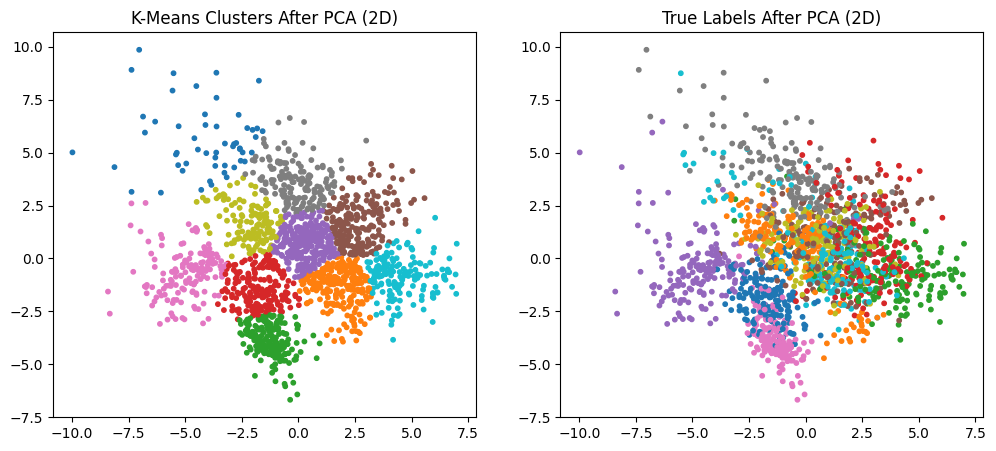

In [ ]:
plt.figure(figsize=(12, 5))

# Plot after PCA
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='tab10', s=10)
plt.title("K-Means Clusters After PCA (2D)")

# Plot true labels after PCA
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
plt.title("True Labels After PCA (2D)")

plt.show()
